In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
from glob import glob

LAYER = 2

feats_a_name = glob(f"../../experiment_data/multiseed_matching/a{LAYER}/feats*1em06*a.csv")[0]
points_a_name = glob(f"../../experiment_data/multiseed_matching/a{LAYER}/points*1em06*a.csv")[0]
feats_b_name = glob(f"../../experiment_data/multiseed_matching/a{LAYER}/feats*1em06*b.csv")[0]
points_b_name = glob(f"../../experiment_data/multiseed_matching/a{LAYER}/points*1em06*b.csv")[0]
feats_c_name = glob(f"../../experiment_data/multiseed_matching/a{LAYER}/feats*1em06*c.csv")[0]
points_c_name = glob(f"../../experiment_data/multiseed_matching/a{LAYER}/points*1em06*c.csv")[0]

feats_a = pd.read_csv(feats_a_name)
points_a = pd.read_csv(points_a_name)
feats_b = pd.read_csv(feats_b_name)
points_b = pd.read_csv(points_b_name)
feats_c = pd.read_csv(feats_c_name)
points_c = pd.read_csv(points_c_name)

In [4]:
def make_merged_feats(points, feats):
    in_feat = pd.merge(points, feats, on=["Feature ID", "Simplification Threshold"], how="left")
    in_feat.drop(columns=["Simplification Threshold", "Homogeneity", "Majority Class", "Major Class Size", "Majority Class Coverage"], inplace=True)
    in_feat.rename(columns={"Feature ID": "fid", "Data Index": "idx", "Loss Start": "lfrom", "Loss End": "lto", "Feature Type": "typ", "Volume": "vol", "Persistence": "pers"}, inplace=True)
    return in_feat

def make_between(a, b):
    between = pd.merge(a, b, on=["idx"], how="inner", suffixes=("_f", "_t"))
    intersection = between.groupby(["fid_f", "fid_t"]).size().reset_index(name="int")
    props = intersection.merge(between, on=["fid_f", "fid_t"], how="left")
    props["union"] = props["vol_f"] + props["vol_t"] - props["int"]
    props["iou"] = props["int"] / props["union"]

    return props

feat_a = make_merged_feats(points_a, feats_a)
feat_b = make_merged_feats(points_b, feats_b)
feat_c = make_merged_feats(points_c, feats_c)

between_ab = make_between(feat_a, feat_b)
between_ac = make_between(feat_a, feat_c)
between_bc = make_between(feat_b, feat_c)
between_ba = make_between(feat_b, feat_a)
between_ca = make_between(feat_c, feat_a)
between_cb = make_between(feat_c, feat_b)

between_ab.head()

,fid_f,fid_t,int,idx,lfrom_f,lto_f,typ_f,pers_f,vol_f,lfrom_t,lto_t,typ_t,pers_t,vol_t,union,iou
0,0,8,2,9598,-0.0,0.205121,minima-saddle,0.000001,427,0.000002,0.218698,saddle-saddle,0.000000,17,442,0.004525
1,0,8,2,19102,-0.0,0.205121,minima-saddle,0.000001,427,0.000002,0.218698,saddle-saddle,0.000000,17,442,0.004525
2,0,29,5,5724,-0.0,0.205121,minima-saddle,0.000001,427,0.000024,0.218720,saddle-saddle,0.000002,314,736,0.006793
3,0,29,5,16988,-0.0,0.205121,minima-saddle,0.000001,427,0.000024,0.218720,saddle-saddle,0.000002,314,736,0.006793
4,0,29,5,18939,-0.0,0.205121,minima-saddle,0.000001,427,0.000024,0.218720,saddle-saddle,0.000002,314,736,0.006793


In [6]:
def get_best_iou_matching(between):
    best_iou = between.groupby("fid_f")["iou"].idxmax()
    best_matching = between.loc[best_iou]
    return best_matching

iou_ab = get_best_iou_matching(between_ab)
iou_ac = get_best_iou_matching(between_ac)

iou_ab_avg = iou_ab["iou"].mean()
iou_ac_avg = iou_ac["iou"].mean()

iou_ab_min_avg = iou_ab[iou_ab["typ_f"].str.contains("minima") & iou_ab["typ_t"].str.contains("minima")]["iou"].mean()
iou_ac_min_avg = iou_ac[iou_ac["typ_f"].str.contains("minima") & iou_ac["typ_t"].str.contains("minima")]["iou"].mean()

iou_ab_avg, iou_ac_avg, iou_ab_min_avg, iou_ac_min_avg

(np.float64(0.04621727992717949),
 np.float64(0.04985852243458001),
 np.float64(0.19676135038291206),
 np.float64(0.18107193115854656))

In [7]:
iou_bc = get_best_iou_matching(between_cb)
iou_bc_avg = iou_bc["iou"].mean()
iou_bc_min_avg = iou_bc[iou_bc["typ_f"].str.contains("minima") & iou_bc["typ_t"].str.contains("minima")]["iou"].mean()

iou_bc_avg, iou_bc_min_avg

(np.float64(0.04160160461716943), np.float64(0.18023874155396227))

<Axes: >

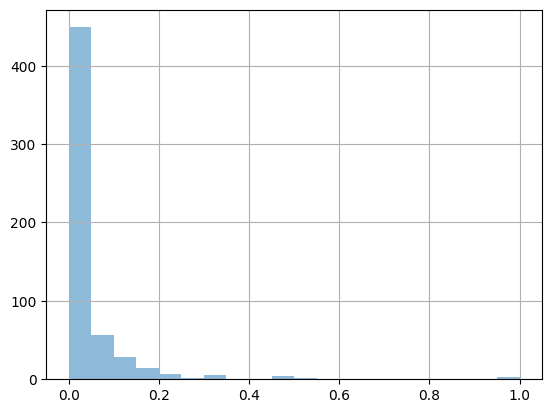

In [8]:
iou_ab["iou"].hist(bins=20, alpha=0.5, label="a-b")

<Axes: >

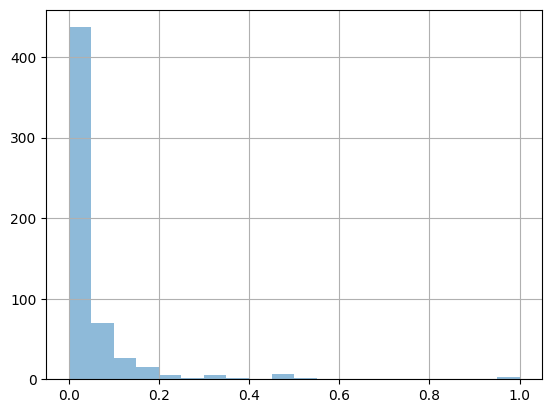

In [9]:
iou_ac["iou"].hist(bins=20, alpha=0.5, label="a-c")

<Axes: >

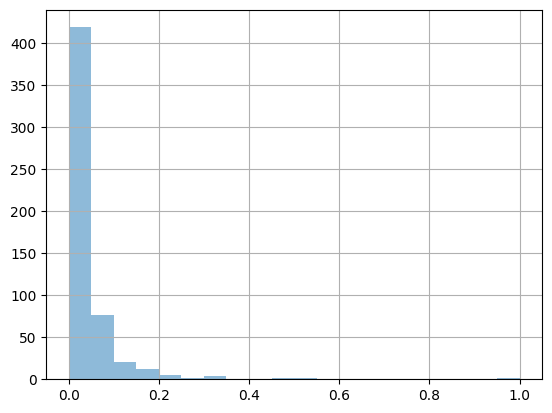

In [10]:
iou_bc["iou"].hist(bins=20, alpha=0.5, label="b-c")